# Q3 - CNN vs ViT vs Pretrained ViT on CIFAR-10 (Colab, self-contained)

All source embedded via `%%writefile`. Hit **Run All**.

**Before running:** Runtime -> Change runtime type -> **T4 GPU** -> Save.

Approx wall times on T4 (single GPU):
- CNN 50 epochs: ~12 min
- ViT 80 epochs: ~25 min
- Pretrained ViT-tiny 3 epochs at 224x224: ~20 min
Total ~1 hour.

In [1]:
!pip -q install timm seaborn scikit-learn

In [2]:
%%writefile models.py
"""
Model definitions for Q3: a custom CNN and a from-scratch Vision Transformer
for CIFAR-10 classification.

Both operate on 32x32 RGB images.
"""
import math

import torch
import torch.nn as nn


# --------------------------------------------------------------------------
# CNN baseline (ResNet-ish: conv + BN + ReLU + residual)
# --------------------------------------------------------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.skip = (nn.Identity() if (stride == 1 and in_c == out_c)
                     else nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride, bias=False),
                                        nn.BatchNorm2d(out_c)))

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return torch.relu(out + self.skip(x))


class SimpleCNN(nn.Module):
    """ResNet-20-ish for CIFAR-10 (~270k params)."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(BasicBlock(64, 64), BasicBlock(64, 64))
        self.layer2 = nn.Sequential(BasicBlock(64, 128, stride=2), BasicBlock(128, 128))
        self.layer3 = nn.Sequential(BasicBlock(128, 256, stride=2), BasicBlock(256, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.drop(x))


# --------------------------------------------------------------------------
# Vision Transformer (from scratch, following the ViT paper)
# --------------------------------------------------------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, d_model=192):
        super().__init__()
        assert img_size % patch_size == 0
        self.n_patches = (img_size // patch_size) ** 2
        # Conv with stride=patch_size is equivalent to flatten-then-linear projection
        self.proj = nn.Conv2d(in_ch, d_model, patch_size, patch_size)

    def forward(self, x):
        x = self.proj(x)              # (B, D, H/ps, W/ps)
        x = x.flatten(2).transpose(1, 2)   # (B, N, D)
        return x


class ViTBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.ln1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(self.ln2(x))
        return x


class ViT(nn.Module):
    """Compact ViT: patch 4x4, d_model=192, depth=6, heads=6."""
    def __init__(self, img_size=32, patch_size=4, num_classes=10,
                 d_model=192, depth=6, n_heads=6, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, d_model)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            ViTBlock(d_model, n_heads, mlp_ratio, dropout) for _ in range(depth)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], 1)
        x = self.drop(x + self.pos_embed)
        for b in self.blocks:
            x = b(x)
        x = self.ln(x)
        return self.head(x[:, 0])


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


if __name__ == "__main__":
    cnn = SimpleCNN(); vit = ViT()
    x = torch.randn(2, 3, 32, 32)
    print("CNN out:", cnn(x).shape, "params:", count_params(cnn))
    print("ViT out:", vit(x).shape, "params:", count_params(vit))


Writing models.py


In [3]:
%%writefile train.py
"""
Train a CNN and a ViT on CIFAR-10, save per-epoch metrics, plot curves,
confusion matrix, and example predictions.

Run:
    python train.py --model cnn --epochs 50
    python train.py --model vit --epochs 50
    python train.py --model pretrained --epochs 5   # (uses timm ViT if available)

Metrics + plots go to ./plots/<model>/
Weights saved every epoch to ./weights/<model>/
"""
import argparse
import json
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from models import SimpleCNN, ViT, count_params


CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]


def build_transforms(img_size=32, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize(img_size) if img_size != 32 else transforms.Lambda(lambda x: x),
            transforms.RandomCrop(img_size, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
        ])
    return transforms.Compose([
        transforms.Resize(img_size) if img_size != 32 else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])


def build_model(name, num_classes=10):
    if name == "cnn":
        return SimpleCNN(num_classes), 32
    if name == "vit":
        return ViT(img_size=32, patch_size=4, num_classes=num_classes,
                   d_model=192, depth=6, n_heads=6), 32
    if name == "pretrained":
        import timm
        model = timm.create_model("vit_tiny_patch16_224", pretrained=True,
                                  num_classes=num_classes)
        return model, 224
    raise ValueError(name)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total = 0; correct = 0; y_true = []; y_pred = []
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    for x, y in loader:
        x = x.to(device); y = y.to(device)
        out = model(x)
        total_loss += loss_fn(out, y).item() * y.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
        y_true.extend(y.cpu().tolist()); y_pred.extend(pred.cpu().tolist())
    return total_loss / total, correct / total, y_true, y_pred


def plot_history(history, out_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = list(range(1, len(history["train_loss"]) + 1))
    ax1.plot(ep, history["train_loss"], label="train"); ax1.plot(ep, history["val_loss"], label="val")
    ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(ep, history["train_acc"], label="train"); ax2.plot(ep, history["val_acc"], label="val")
    ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.savefig(out_path, dpi=120); plt.close()


def plot_confusion(y_true, y_pred, out_path):
    import seaborn as sns
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix")
    plt.tight_layout(); plt.savefig(out_path, dpi=120); plt.close()


def save_examples(model, loader, device, out_path, n=16):
    model.eval()
    x, y = next(iter(loader))
    x_in = x[:n].to(device)
    with torch.no_grad():
        pred = model(x_in).argmax(1).cpu()
    x_show = x[:n] * torch.tensor(CIFAR_STD)[:, None, None] + torch.tensor(CIFAR_MEAN)[:, None, None]
    x_show = x_show.clamp(0, 1)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(x_show[i].permute(1, 2, 0).numpy())
        ok = pred[i].item() == y[i].item()
        ax.set_title(f"p:{CLASSES[pred[i]]}\nt:{CLASSES[y[i]]}",
                     color="green" if ok else "red", fontsize=8)
        ax.axis("off")
    plt.tight_layout(); plt.savefig(out_path, dpi=120); plt.close()


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--model", choices=["cnn", "vit", "pretrained"], required=True)
    p.add_argument("--data_root", type=str, default="./data")
    p.add_argument("--weights_dir", type=str, default="./weights")
    p.add_argument("--plots_dir", type=str, default="./plots")
    p.add_argument("--epochs", type=int, default=50)
    p.add_argument("--batch_size", type=int, default=128)
    p.add_argument("--lr", type=float, default=3e-4)
    p.add_argument("--weight_decay", type=float, default=5e-4)
    p.add_argument("--num_workers", type=int, default=2)
    p.add_argument("--patience", type=int, default=10)
    p.add_argument("--resume", action="store_true")
    args = p.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    weights_dir = Path(args.weights_dir) / args.model; weights_dir.mkdir(parents=True, exist_ok=True)
    plots_dir = Path(args.plots_dir) / args.model; plots_dir.mkdir(parents=True, exist_ok=True)

    model, img_size = build_model(args.model)
    model = model.to(device)
    print(f"Model: {args.model} ({count_params(model):,} params) @ {img_size}x{img_size}")

    train_ds = datasets.CIFAR10(args.data_root, train=True, download=True,
                                transform=build_transforms(img_size, train=True))
    test_ds = datasets.CIFAR10(args.data_root, train=False, download=True,
                               transform=build_transforms(img_size, train=False))
    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,
                              num_workers=args.num_workers, pin_memory=device.type == "cuda")
    val_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False,
                            num_workers=args.num_workers, pin_memory=device.type == "cuda")

    opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=args.epochs)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc = 0.0; bad = 0; start_epoch = 0

    ckpt_path = weights_dir / "latest.pt"
    if args.resume and ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"]); history = ck["history"]
        best_acc = ck["best_acc"]; start_epoch = ck["epoch"] + 1
        print(f"Resumed epoch {start_epoch}")

    total_train_time = 0.0
    for epoch in range(start_epoch, args.epochs):
        t0 = time.time(); model.train()
        ep_loss = 0.0; ep_correct = 0; ep_total = 0
        for x, y in train_loader:
            x = x.to(device); y = y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item() * y.size(0)
            ep_correct += (out.argmax(1) == y).sum().item()
            ep_total += y.size(0)
        sched.step()

        train_loss = ep_loss / ep_total; train_acc = ep_correct / ep_total
        val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, device)
        dt = time.time() - t0; total_train_time += dt
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
        print(f"ep {epoch} train_loss {train_loss:.3f} train_acc {train_acc:.3f} "
              f"val_loss {val_loss:.3f} val_acc {val_acc:.3f} time {dt:.1f}s")

        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "opt": opt.state_dict(), "sched": sched.state_dict(),
                    "history": history, "best_acc": best_acc},
                   ckpt_path)

        if val_acc > best_acc:
            best_acc = val_acc; bad = 0
            torch.save(model.state_dict(), weights_dir / "best.pt")
        else:
            bad += 1
            if bad >= args.patience:
                print(f"Early stopping at epoch {epoch} (best val_acc={best_acc:.3f})")
                break

    # Reload best weights for final eval
    best_path = weights_dir / "best.pt"
    if best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location=device))
    _, final_acc, y_true, y_pred = evaluate(model, val_loader, device)

    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    results = {
        "model": args.model, "params": count_params(model),
        "best_val_acc": float(final_acc),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1),
        "total_train_time_sec": float(total_train_time),
        "epochs_run": len(history["train_loss"]),
        "history": history,
    }
    with open(plots_dir / "results.json", "w") as f:
        json.dump(results, f, indent=2)

    plot_history(history, plots_dir / "loss_acc_curves.png")
    plot_confusion(y_true, y_pred, plots_dir / "confusion_matrix.png")
    save_examples(model, val_loader, device, plots_dir / "example_preds.png")
    with open(plots_dir / "classification_report.txt", "w") as f:
        f.write(classification_report(y_true, y_pred, target_names=CLASSES))

    print(f"\nFinished. best_val_acc={final_acc:.4f}  f1={f1:.4f}  "
          f"params={count_params(model):,}  time={total_train_time:.1f}s")
    print(f"Artefacts in {plots_dir}")


if __name__ == "__main__":
    main()


Writing train.py


In [4]:
%%writefile compare.py
"""
Aggregate results from CNN / ViT / pretrained runs into a single comparison
table + bar charts.

Run AFTER training all three models:
    python train.py --model cnn --epochs 50
    python train.py --model vit --epochs 50
    python train.py --model pretrained --epochs 5
    python compare.py
"""
import json
from pathlib import Path

import matplotlib.pyplot as plt


def load_results(plots_dir="./plots"):
    rows = {}
    for sub in Path(plots_dir).iterdir():
        rj = sub / "results.json"
        if rj.exists():
            rows[sub.name] = json.loads(rj.read_text())
    return rows


def main():
    rows = load_results()
    if not rows:
        print("No results found. Run train.py for at least one model first.")
        return

    # Table
    header = f"{'model':<12}{'params':>12}{'val_acc':>10}{'f1':>8}{'time(s)':>10}{'epochs':>8}"
    print(header); print("-" * len(header))
    for name, r in rows.items():
        print(f"{name:<12}{r['params']:>12,}{r['best_val_acc']:>10.4f}"
              f"{r['f1_macro']:>8.3f}{r['total_train_time_sec']:>10.1f}"
              f"{r['epochs_run']:>8}")

    # Accuracy + parameter count bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    names = list(rows.keys())
    ax1.bar(names, [rows[n]["best_val_acc"] for n in names], color="steelblue")
    ax1.set_title("Best val accuracy"); ax1.set_ylim(0, 1)
    ax2.bar(names, [rows[n]["params"] / 1e6 for n in names], color="indianred")
    ax2.set_title("Parameters (M)")
    plt.tight_layout(); plt.savefig("plots/comparison.png", dpi=120); plt.close()

    # Overlay training curves
    plt.figure(figsize=(8, 4))
    for n in names:
        plt.plot(rows[n]["history"]["val_acc"], label=f"{n} val")
    plt.title("Validation accuracy per epoch"); plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend()
    plt.tight_layout(); plt.savefig("plots/val_acc_curves.png", dpi=120); plt.close()
    print("\nSaved plots/comparison.png + plots/val_acc_curves.png")


if __name__ == "__main__":
    main()


Writing compare.py


In [5]:
# CNN baseline (ResNet-ish)
!python train.py --model cnn \
   --data_root /content/data \
   --weights_dir /content/weights \
   --plots_dir /content/plots \
   --epochs 50 --batch_size 128 --lr 3e-4

Using device: cuda
Model: cnn (2,777,674 params) @ 32x32
100% 170M/170M [00:03<00:00, 47.9MB/s]
ep 0 train_loss 1.592 train_acc 0.496 val_loss 1.193 val_acc 0.582 time 35.7s
ep 1 train_loss 1.240 train_acc 0.676 val_loss 0.882 val_acc 0.695 time 34.6s
ep 2 train_loss 1.088 train_acc 0.750 val_loss 0.730 val_acc 0.760 time 37.6s
ep 3 train_loss 1.003 train_acc 0.792 val_loss 0.718 val_acc 0.769 time 38.3s
ep 4 train_loss 0.943 train_acc 0.820 val_loss 0.595 val_acc 0.809 time 37.7s
ep 5 train_loss 0.897 train_acc 0.841 val_loss 0.623 val_acc 0.810 time 37.9s
ep 6 train_loss 0.858 train_acc 0.858 val_loss 0.484 val_acc 0.846 time 37.7s
ep 7 train_loss 0.825 train_acc 0.872 val_loss 0.539 val_acc 0.831 time 37.2s
ep 8 train_loss 0.802 train_acc 0.882 val_loss 0.455 val_acc 0.857 time 37.3s
ep 9 train_loss 0.780 train_acc 0.893 val_loss 0.449 val_acc 0.861 time 37.3s
ep 10 train_loss 0.759 train_acc 0.901 val_loss 0.450 val_acc 0.859 time 37.2s
ep 11 train_loss 0.738 train_acc 0.910 val_lo

In [6]:
# ViT from scratch (compact)
!python train.py --model vit \
   --data_root /content/data \
   --weights_dir /content/weights \
   --plots_dir /content/plots \
   --epochs 80 --batch_size 128 --lr 5e-4

Using device: cuda
Model: vit (2,693,578 params) @ 32x32
ep 0 train_loss 1.873 train_acc 0.343 val_loss 1.566 val_acc 0.425 time 44.7s
ep 1 train_loss 1.636 train_acc 0.470 val_loss 1.345 val_acc 0.519 time 39.3s
ep 2 train_loss 1.535 train_acc 0.517 val_loss 1.309 val_acc 0.538 time 39.2s
ep 3 train_loss 1.473 train_acc 0.548 val_loss 1.193 val_acc 0.585 time 39.5s
ep 4 train_loss 1.421 train_acc 0.575 val_loss 1.169 val_acc 0.582 time 38.7s
ep 5 train_loss 1.375 train_acc 0.594 val_loss 1.161 val_acc 0.595 time 38.9s
ep 6 train_loss 1.344 train_acc 0.609 val_loss 1.059 val_acc 0.632 time 39.2s
ep 7 train_loss 1.305 train_acc 0.629 val_loss 1.027 val_acc 0.644 time 38.9s
ep 8 train_loss 1.273 train_acc 0.645 val_loss 0.975 val_acc 0.659 time 38.9s
ep 9 train_loss 1.247 train_acc 0.658 val_loss 0.960 val_acc 0.674 time 38.9s
ep 10 train_loss 1.212 train_acc 0.676 val_loss 0.883 val_acc 0.703 time 39.0s
ep 11 train_loss 1.187 train_acc 0.688 val_loss 0.878 val_acc 0.701 time 38.9s
ep 12

In [7]:
# Pretrained ViT-tiny fine-tune (224x224, smaller batch)
!python train.py --model pretrained \
   --data_root /content/data \
   --weights_dir /content/weights \
   --plots_dir /content/plots \
   --epochs 3 --batch_size 64 --lr 1e-4

Using device: cuda
model.safetensors: 100% 22.9M/22.9M [00:01<00:00, 20.7MB/s]
Model: pretrained (5,526,346 params) @ 224x224
ep 0 train_loss 0.685 train_acc 0.926 val_loss 0.273 val_acc 0.935 time 206.9s
ep 1 train_loss 0.578 train_acc 0.968 val_loss 0.202 val_acc 0.962 time 206.6s
ep 2 train_loss 0.530 train_acc 0.988 val_loss 0.181 val_acc 0.972 time 207.4s

Finished. best_val_acc=0.9715  f1=0.9716  params=5,526,346  time=620.9s
Artefacts in /content/plots/pretrained


In [8]:
# Comparison table + charts
import os
os.chdir('/content')
!python compare.py

model             params   val_acc      f1   time(s)  epochs
------------------------------------------------------------
pretrained     5,526,346    0.9715   0.972     620.9       3
vit            2,693,578    0.8219   0.821    2148.0      55
cnn            2,777,674    0.9278   0.928    1869.1      50

Saved plots/comparison.png + plots/val_acc_curves.png


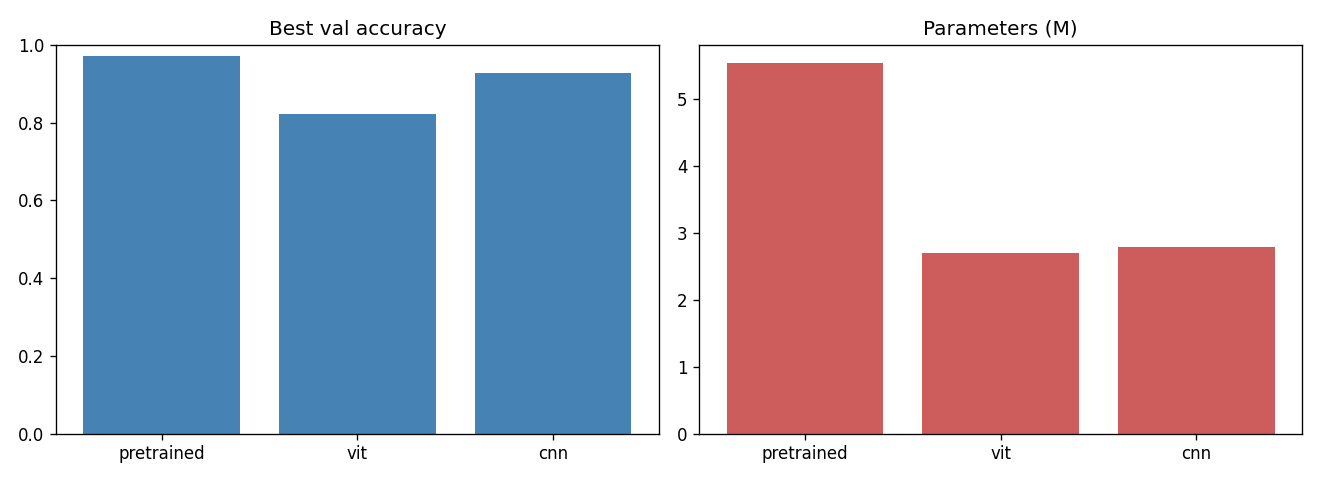

In [9]:
# Inline preview of the aggregated comparison chart
from IPython.display import Image
Image('/content/plots/comparison.png')

In [10]:
# Package weights + plots for download, then download to your laptop.
!tar -czf /content/q3_results.tar.gz -C /content weights plots
from google.colab import files
files.download('/content/q3_results.tar.gz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>